In [15]:
from scipy.sparse import load_npz
import joblib
from pathlib import Path
import pandas as pd
Project_DIR = Path.cwd().resolve()
if Project_DIR.name == "notebook":
    Project_DIR = Project_DIR.parent

Data_DIR = Project_DIR / "DATA"
X = load_npz(Data_DIR / "tfidf_features.npz")
vectorizer = joblib.load(Data_DIR / "tfidf_vectorizer.pkl")
y = pd.read_csv(Data_DIR / "labels.csv")["text_type"]

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

**modelling**

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, f1_score,accuracy_score, confusion_matrix
from xgboost import XGBClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

**Baseline Model Logistic_Regression**

In [18]:


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print(accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

0.9336609336609336 0.9181014745759074


**Navies Bayes**

In [19]:
nv = MultinomialNB()
nv.fit(X_train, y_train)
pred = nv.predict(X_test)
print(accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

0.9100737100737101 0.8885081731632836


**KNN**

In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print(accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

0.7872235872235872 0.7162051221600947


**SVM**

In [21]:
from sklearn.svm import SVC
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
pred = svm.predict(X_test)
print(accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

0.9405405405405406 0.9273171594199305


**Random Forest**

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print(accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

0.9388206388206388 0.9237172491240051


**Gradient Boosting**

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
print(accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

0.9024570024570024 0.875963585360849


**xgb boosting**

In [33]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print(accuracy_score(y_test, pred), f1_score(y_test, pred, average="macro"))

0.9358722358722359 0.9214695275345312


**Hyper_parameter_tunning**

In [25]:
from sklearn.model_selection import GridSearchCV

models = {
    "logistic_regression": GridSearchCV(
        LogisticRegression(max_iter=1000),
        {"C": [0.1, 1, 10]},
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ),

    "random_forest": GridSearchCV(
        RandomForestClassifier(random_state=42),
        {"n_estimators": [100, 300], "max_depth": [None, 10, 20]},
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ),

    "gradient_boosting": GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [100, 300],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1]
        },
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ),

    "naive_bayes": GridSearchCV(
        MultinomialNB(),
        {"alpha": [0.01, 0.1, 0.5, 1.0]},
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ),

    "xgboost": GridSearchCV(
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ),
        {
            "n_estimators": [100, 300],
            "max_depth": [3, 6],
            "learning_rate": [0.05, 0.1]
        },
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    ),

    "svm": GridSearchCV(
        SVC(kernel="linear", random_state=42),
        {"C": [0.1, 1, 10]},
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    ),

    "knn": GridSearchCV(
        KNeighborsClassifier(),
        {"n_neighbors": [2, 3, 5]},
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: {model.best_params_}")

logistic_regression: {'C': 10}
random_forest: {'max_depth': None, 'n_estimators': 300}
gradient_boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
naive_bayes: {'alpha': 0.1}
xgboost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
svm: {'C': 1}
knn: {'n_neighbors': 2}


In [27]:
from sklearn.ensemble import VotingClassifier

voting_estimators = [
    ("logistic_regression", models["logistic_regression"].best_estimator_),
    ("random_forest", models["random_forest"].best_estimator_),
    ("gradient_boosting", models["gradient_boosting"].best_estimator_),
    ("naive_bayes", models["naive_bayes"].best_estimator_),
    ("xgboost", models["xgboost"].best_estimator_),
    ("knn", models["knn"].best_estimator_),
]

voting_clf = VotingClassifier(
    estimators=voting_estimators,
    voting="soft",
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)

pred = voting_clf.predict(X_test)
print(
    accuracy_score(y_test, pred),
    f1_score(y_test, pred, average="macro")
)

0.9496314496314496 0.9378997746201325


**Compare all models on the test set**

In [29]:
models = {**models, "voting_classifier": voting_clf}
for name, model in models.items():
    pred = model.predict(X_test)
    print(f"{name}: acc = {accuracy_score(y_test, pred)},f1_score = {f1_score(y_test, pred, average='macro')}")

logistic_regression: acc = 0.9380835380835381,f1_score = 0.9249610187110187
random_forest: acc = 0.9395577395577396,f1_score = 0.9246157603822925
gradient_boosting: acc = 0.932923832923833,f1_score = 0.9163646948227043
naive_bayes: acc = 0.9093366093366093,f1_score = 0.8887442598096333
xgboost: acc = 0.9368550368550369,f1_score = 0.9226730596795958
svm: acc = 0.9405405405405406,f1_score = 0.9273171594199305
knn: acc = 0.788943488943489,f1_score = 0.7176641127363395
voting_classifier: acc = 0.9496314496314496,f1_score = 0.9378997746201325


**Look deeper at the best model**

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2868
           1       0.95      0.87      0.91      1202

    accuracy                           0.95      4070
   macro avg       0.95      0.93      0.94      4070
weighted avg       0.95      0.95      0.95      4070



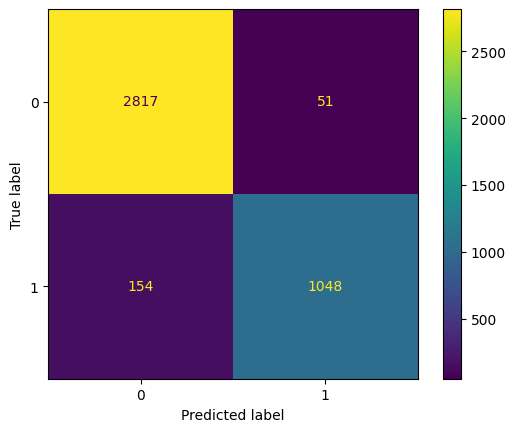

In [30]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
best_pred = voting_clf.predict(X_test)
print(classification_report(y_test, best_pred))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.show()

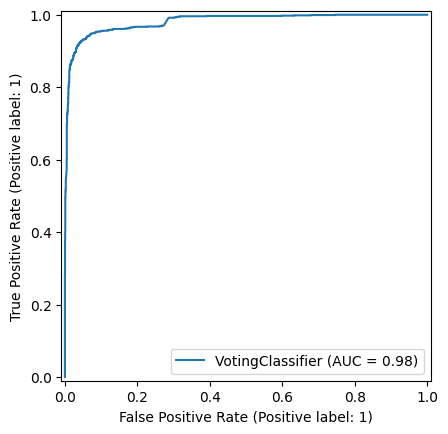

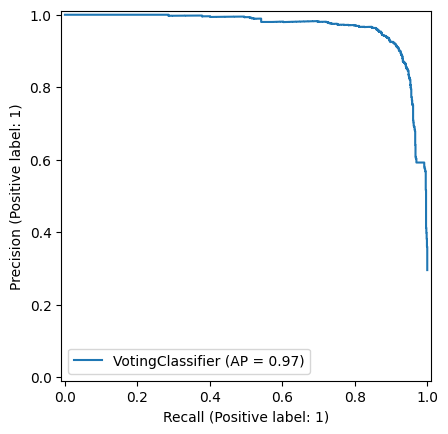

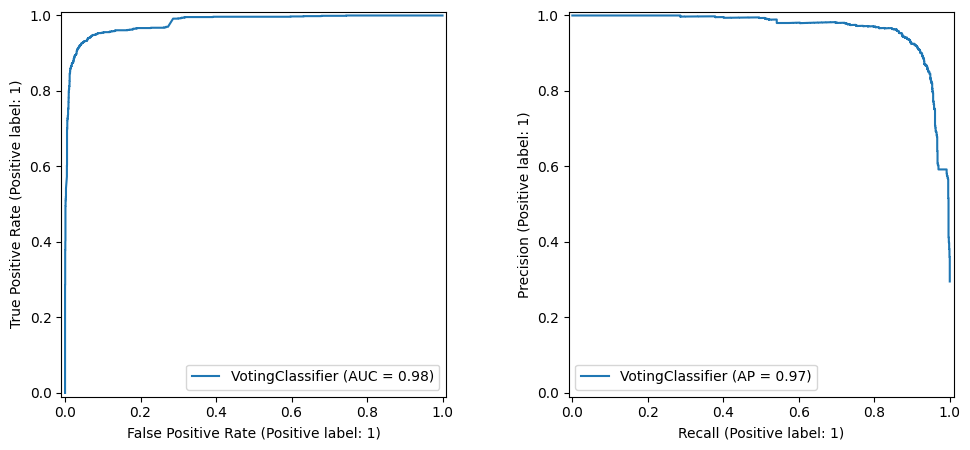

In [31]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
RocCurveDisplay.from_estimator(voting_clf, X_test, y_test)
PrecisionRecallDisplay.from_estimator(voting_clf, X_test, y_test)
fig , ax = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(voting_clf, X_test, y_test, ax=ax[0])
PrecisionRecallDisplay.from_estimator(voting_clf, X_test, y_test, ax=ax[1])
plt.show()

logistic_regression ROC-AUC: 0.9765
naive_bayes ROC-AUC: 0.9683
knn ROC-AUC: 0.7652


AttributeError: This 'GridSearchCV' has no attribute 'predict_proba'

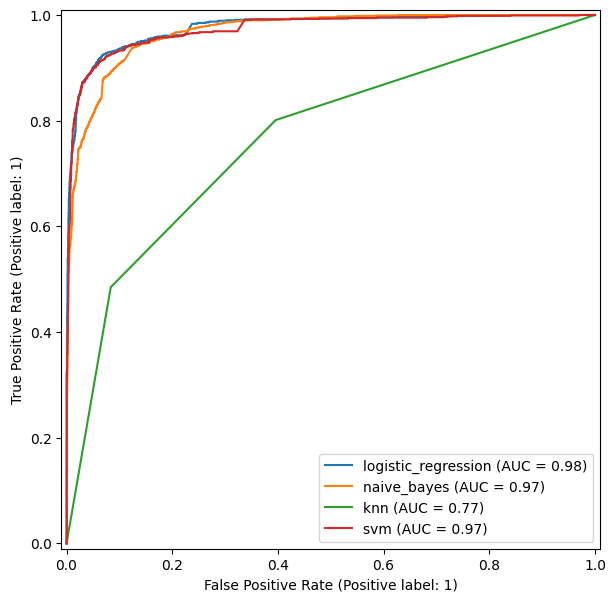

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

model_names = [
    "logistic_regression",
    "naive_bayes",
    "knn",
    "svm",
    "random_forest",
    "gradient_boosting",
]

fig, ax = plt.subplots(figsize=(9, 7))

for name in model_names:
    model = models[name]

    # Works with predict_proba() or decision_function()
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=name
    )

    print(f"{name} ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_title("ROC Curves for All Models")
ax.legend()
plt.show()